In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

processed_dir = Path("../data/processed")

a_x = pd.read_csv(processed_dir / "a_x_100.csv", index_col=0).squeeze("columns")
b_x = pd.read_csv(processed_dir / "b_x_100.csv", index_col=0).squeeze("columns")
k_t = pd.read_csv(processed_dir / "k_t_100.csv", index_col=0).squeeze("columns")

a_x.index = a_x.index.astype(int)
b_x.index = b_x.index.astype(int)
k_t.index = k_t.index.astype(int)

print(a_x.head())
print(b_x.head())
print(k_t.head())

Age_num
0   -4.175754
1   -6.758425
2   -7.244202
3   -7.527367
4   -7.744006
Name: 0, dtype: float64
Age_num
0    0.021295
1    0.024906
2    0.022391
3    0.021934
4    0.022039
Name: b_x, dtype: float64
1933    76.063197
1934    77.783083
1935    76.160277
1936    77.843550
1937    73.759236
Name: k_t, dtype: float64


In [2]:
k_diff = k_t.diff().dropna()

k_diff.head()

1934    1.719885
1935   -1.622806
1936    1.683273
1937   -4.084314
1938   -7.362124
Name: k_t, dtype: float64

In [3]:
drift = k_diff.mean()
sigma = k_diff.std()

print("Estimated drift:", drift)
print("Estimated annual shock std:", sigma)

Estimated drift: -1.3320070840470584
Estimated annual shock std: 2.3463997685015343


In [4]:
last_year = k_t.index.max()
last_k = k_t.iloc[-1]

forecast_years = np.arange(last_year + 1, 2051)
h = np.arange(1, len(forecast_years) + 1)

k_forecast_values = last_k + h * drift

k_forecast = pd.Series(
    k_forecast_values,
    index=forecast_years,
    name="k_t_forecast"
)

k_forecast.head()

2025   -46.481454
2026   -47.813462
2027   -49.145469
2028   -50.477476
2029   -51.809483
Name: k_t_forecast, dtype: float64

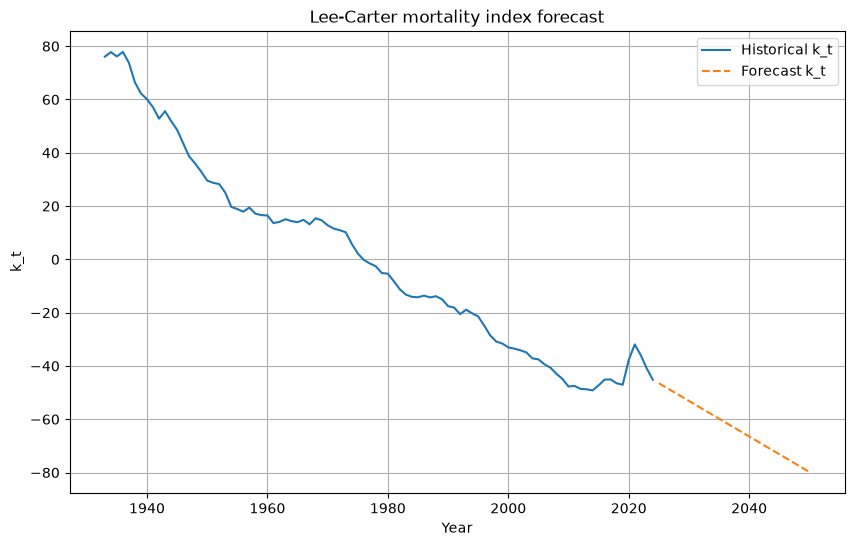

In [5]:
plt.figure(figsize=(10, 6))

plt.plot(k_t.index, k_t.values, label="Historical k_t")
plt.plot(k_forecast.index, k_forecast.values, linestyle="--", label="Forecast k_t")

plt.xlabel("Year")
plt.ylabel("k_t")
plt.title("Lee-Carter mortality index forecast")
plt.legend()
plt.grid(True)
plt.show()

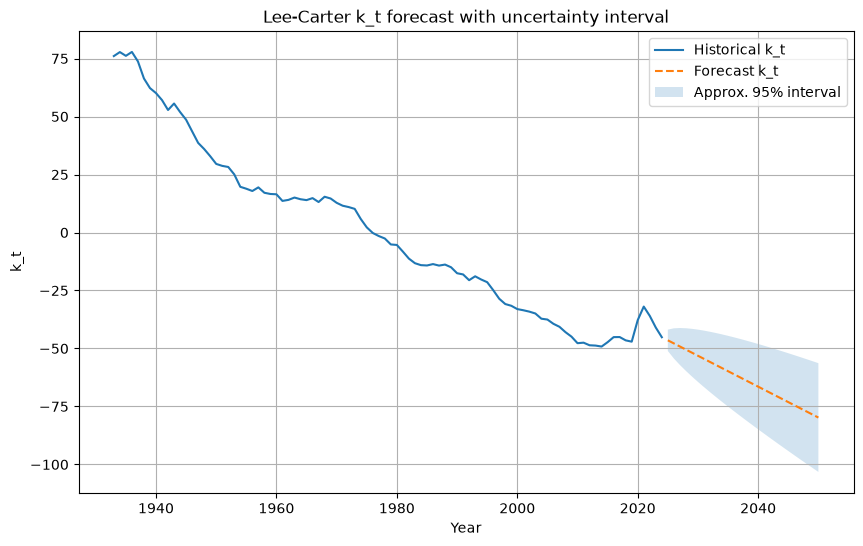

In [6]:
se_forecast = sigma * np.sqrt(h)

lower_95 = k_forecast_values - 1.96 * se_forecast
upper_95 = k_forecast_values + 1.96 * se_forecast

plt.figure(figsize=(10, 6))

plt.plot(k_t.index, k_t.values, label="Historical k_t")
plt.plot(k_forecast.index, k_forecast.values, linestyle="--", label="Forecast k_t")

plt.fill_between(
    forecast_years,
    lower_95,
    upper_95,
    alpha=0.2,
    label="Approx. 95% interval"
)

plt.xlabel("Year")
plt.ylabel("k_t")
plt.title("Lee-Carter k_t forecast with uncertainty interval")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
forecast_log_mx = pd.DataFrame(
    np.outer(b_x.values, k_forecast.values),
    index=b_x.index,
    columns=k_forecast.index
)

forecast_log_mx = forecast_log_mx.add(a_x, axis=0)

forecast_mx = np.exp(forecast_log_mx)

forecast_mx.head()

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
Age_num,,,,,,,,,,,,,,,,,,,,,
0,0.005710,0.005550,0.005395,0.005244,0.005097,0.004955,0.004816,0.004681,0.004551,0.004423,...,0.003627,0.003525,0.003427,0.003331,0.003238,0.003147,0.003059,0.002974,0.002890,0.002810
1,0.000365,0.000353,0.000341,0.000330,0.000319,0.000309,0.000299,0.000289,0.000280,0.000271,...,0.000215,0.000208,0.000201,0.000194,0.000188,0.000182,0.000176,0.000170,0.000165,0.000159
2,0.000252,0.000245,0.000238,0.000231,0.000224,0.000217,0.000211,0.000205,0.000199,0.000193,...,0.000157,0.000152,0.000147,0.000143,0.000139,0.000135,0.000131,0.000127,0.000123,0.000120
3,0.000194,0.000189,0.000183,0.000178,0.000173,0.000168,0.000163,0.000158,0.000154,0.000149,...,0.000122,0.000118,0.000115,0.000111,0.000108,0.000105,0.000102,0.000099,0.000096,0.000094
4,0.000156,0.000151,0.000147,0.000142,0.000138,0.000134,0.000130,0.000127,0.000123,0.000119,...,0.000097,0.000094,0.000092,0.000089,0.000086,0.000084,0.000082,0.000079,0.000077,0.000075


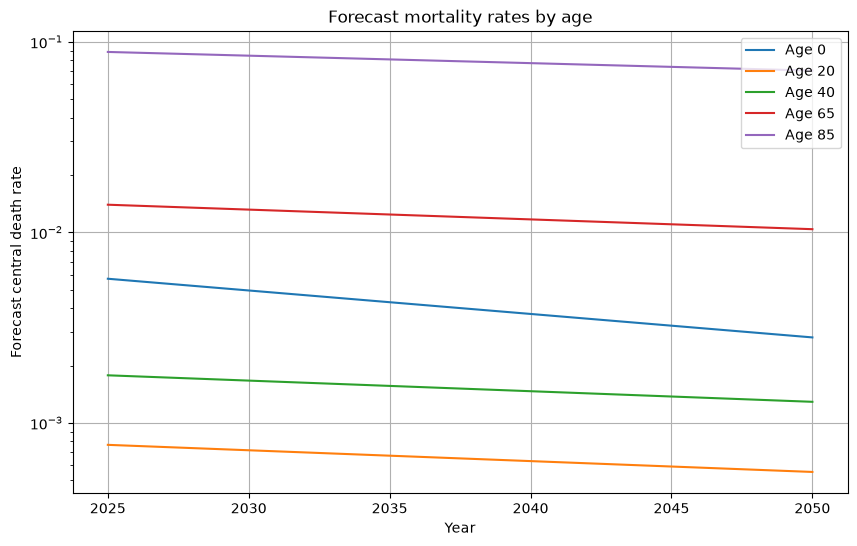

In [8]:
selected_ages = [0, 20, 40, 65, 85]

plt.figure(figsize=(10, 6))

for age in selected_ages:
    plt.plot(
        forecast_mx.columns,
        forecast_mx.loc[age],
        label=f"Age {age}"
    )

plt.yscale("log")
plt.xlabel("Year")
plt.ylabel("Forecast central death rate")
plt.title("Forecast mortality rates by age")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
forecast_dir = Path("../data/processed")

k_forecast.to_csv(forecast_dir / "k_t_forecast_2050.csv")
forecast_log_mx.to_csv(forecast_dir / "forecast_log_mx_2050.csv")
forecast_mx.to_csv(forecast_dir / "forecast_mx_2050.csv")

print("Saved mortality forecasts through 2050.")

Saved mortality forecasts through 2050.


## Conclusion

The Lee-Carter mortality index was forecasted using a random walk with drift. The negative drift indicates continued mortality improvement over time. The projected mortality index was then used to reconstruct future age-specific mortality rates through 2050.